# PneumoScan — Détection de pneumonie (RSNA) avec YOLO11m — v5

**Nouveauté principale de cette version : reprise automatique.**
Si ce commit est interrompu (limite 12h de Kaggle, ou quota GPU épuisé), il suffit de :
1. Télécharger `last.pt` depuis l'onglet Output de cette version
2. Le mettre en Kaggle Dataset, nommé exactement **`pneumoscan-v5-checkpoint`**
3. Rattacher ce dataset en Input à un nouveau commit de CE MÊME notebook
4. Relancer « Save & Run All (Commit) » — le notebook détecte le checkpoint tout seul et reprend, sans qu'aucune modification de code ne soit nécessaire.

**Reprend de la v4 (meilleur résultat : mAP@0.5 = 0,406 à l'epoch 55/60), avec :**
- Garde CLAHE, `RATIO_NEGATIFS=1.5`, `box=8.5`, `mosaic=0.3` (déjà prouvés efficaces)
- `epochs=70` (plus de marge pour continuer à converger), `patience=15`
- `save_period=5` — checkpoint versionné toutes les 5 epochs


In [1]:
!pip install -q ultralytics pydicom opencv-python-headless

import os, random, shutil
import numpy as np
import pandas as pd
import pydicom
import cv2
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import torch

print("GPU disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Appareil :", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 4.4 MB/s eta 0:00:00
GPU disponible : True
Appareil : Tesla T4


## 0. Détection automatique d'une reprise possible

In [2]:
# Si un dataset "pneumoscan-v5-checkpoint" est rattache en Input, on va reprendre
# l'entrainement depuis le dernier point sauvegarde, plutot que de repartir a zero.
CHECKPOINT_SOURCE = None
for dossier in os.listdir('/kaggle/input') if os.path.exists('/kaggle/input') else []:
    if 'checkpoint' in dossier.lower():
        chemin_pt = f'/kaggle/input/{dossier}'
        for f in os.listdir(chemin_pt):
            if f.endswith('.pt'):
                CHECKPOINT_SOURCE = f'{chemin_pt}/{f}'
                break

if CHECKPOINT_SOURCE:
    print(f"Checkpoint trouve : {CHECKPOINT_SOURCE}")
    print("L'entrainement va REPRENDRE depuis ce point, pas repartir de zero.")
else:
    print("Aucun checkpoint trouve : nouvel entrainement depuis le modele pre-entraine yolo11m.")


Aucun checkpoint trouve : nouvel entrainement depuis le modele pre-entraine yolo11m.


## 1. Configuration et chargement des annotations

In [3]:
RSNA = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge'
WORK = '/kaggle/working/dataset'
RUN_NAME = 'pneumoscan_yolo11m_v5'
RUN_DIR = f'/kaggle/working/pneumoscan_runs/{RUN_NAME}'

TAILLE_PNG = 640        # reste a 640 : evite OOM et timeout, deja valide en v4
RATIO_NEGATIFS = 1.5    # deja le meilleur compromis trouve en v4
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

labels = pd.read_csv(f'{RSNA}/stage_2_train_labels.csv')
print("Lignes :", len(labels))
print("Patients uniques :", labels['patientId'].nunique())
labels.head()


Lignes : 30227
Patients uniques : 26684


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


## 2. Sélection du dataset

In [4]:
boites = {}
for r in labels.itertuples(index=False):
    d = boites.setdefault(r.patientId, [])
    if r.Target == 1 and not pd.isna(r.x):
        d.append([r.x, r.y, r.width, r.height])

positifs = [p for p, b in boites.items() if len(b) > 0]
negatifs = [p for p, b in boites.items() if len(b) == 0]
negatifs_retenus = random.sample(negatifs, min(len(negatifs), int(len(positifs) * RATIO_NEGATIFS)))

ids = positifs + negatifs_retenus
cible = [1] * len(positifs) + [0] * len(negatifs_retenus)
print(f"Positifs : {len(positifs)} | Negatifs retenus : {len(negatifs_retenus)} | Total : {len(ids)}")

from sklearn.model_selection import train_test_split
train_ids, val_ids = train_test_split(ids, test_size=0.2, random_state=SEED, stratify=cible)
print(f"Train : {len(train_ids)} | Val : {len(val_ids)}")


Positifs : 6012 | Negatifs retenus : 9018 | Total : 15030
Train : 12024 | Val : 3006


## 3. Conversion DICOM → PNG avec CLAHE + labels YOLO

In [5]:
for split in ['train', 'val']:
    os.makedirs(f'{WORK}/images/{split}', exist_ok=True)
    os.makedirs(f'{WORK}/labels/{split}', exist_ok=True)

def convertir_avec_clahe(pid, split):
    ds = pydicom.dcmread(f'{RSNA}/stage_2_train_images/{pid}.dcm')
    img = ds.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-6) * 255.0
    img = img.astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    h, w = img.shape
    im = Image.fromarray(img)
    if TAILLE_PNG:
        im = im.resize((TAILLE_PNG, TAILLE_PNG), Image.BILINEAR)
    im.save(f'{WORK}/images/{split}/{pid}.png')

    lignes = []
    for x, y, bw, bh in boites[pid]:
        cx, cy = (x + bw / 2) / w, (y + bh / 2) / h
        nw, nh = bw / w, bh / h
        lignes.append(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
    with open(f'{WORK}/labels/{split}/{pid}.txt', 'w') as f:
        f.write('\n'.join(lignes))

for split, liste in [('train', train_ids), ('val', val_ids)]:
    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(lambda p: convertir_avec_clahe(p, split), liste), total=len(liste), desc=f"Conversion {split}"))

print("Images train :", len(os.listdir(f'{WORK}/images/train')))
print("Images val   :", len(os.listdir(f'{WORK}/images/val')))


Conversion train:   0%|          | 0/12024 [00:00<?, ?it/s]

Conversion val:   0%|          | 0/3006 [00:00<?, ?it/s]

Images train : 12024
Images val   : 3006


In [6]:
data_yaml = f"""path: {WORK}
train: images/train
val: images/val
nc: 1
names:
  0: pneumonie
"""
with open(f'{WORK}/data.yaml', 'w') as f:
    f.write(data_yaml)
print(data_yaml)


path: /kaggle/working/dataset
train: images/train
val: images/val
nc: 1
names:
  0: pneumonie



## 4. Entraînement (v5) — avec reprise automatique

Si un checkpoint a été détecté à l'étape 0, il est copié au bon endroit et l'entraînement reprend avec `resume=True`. Sinon, entraînement classique depuis `yolo11m.pt`.

In [7]:
from ultralytics import YOLO

if CHECKPOINT_SOURCE:
    os.makedirs(f'{RUN_DIR}/weights', exist_ok=True)
    shutil.copy(CHECKPOINT_SOURCE, f'{RUN_DIR}/weights/last.pt')
    model = YOLO(f'{RUN_DIR}/weights/last.pt')
    print("Reprise de l'entrainement depuis le checkpoint...")
    resultats = model.train(resume=True)
else:
    model = YOLO('yolo11m.pt')
    resultats = model.train(
        data=f'{WORK}/data.yaml',
        epochs=70,                  # v5 : plus de marge que v4 (60) pour continuer a converger
        imgsz=TAILLE_PNG,
        batch=16,
        save_period=5,
        project='/kaggle/working/pneumoscan_runs',
        name=RUN_NAME,
        exist_ok=True,
        seed=SEED,

        optimizer='AdamW',
        lr0=0.0015, lrf=0.01, cos_lr=True,
        warmup_epochs=3.0, weight_decay=0.0005,
        patience=15,

        box=8.5, cls=0.5, dfl=1.5,

        hsv_h=0.0, hsv_s=0.0, hsv_v=0.4,
        degrees=5.0, translate=0.08, scale=0.2,
        shear=0.0, perspective=0.0,
        fliplr=0.5, flipud=0.0,
        mosaic=0.3, close_mosaic=15, mixup=0.0, erasing=0.1,

        single_cls=True, amp=True, plots=True, workers=4, cache=False,
    )


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.126 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=8.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.1, exist_ok=True, fliplr=0.5, flipud=0.0, 

## 5. Si ce commit se termine sans erreur — évaluation complète

⚠️ Si l'entraînement ci-dessus a été interrompu par Kaggle (timeout ou quota), cette cellule et les suivantes ne s'exécuteront pas dans CE commit — c'est normal. Suis les instructions du haut pour créer un nouveau commit de reprise, qui ira jusqu'ici une fois l'entraînement vraiment termine.

In [8]:
best = YOLO(f'{RUN_DIR}/weights/best.pt')

m = best.val(data=f'{WORK}/data.yaml', imgsz=TAILLE_PNG, split='val', plots=True)

tableau = pd.DataFrame([{
    'Precision (P)': round(m.box.mp, 4),
    'Rappel (R)':    round(m.box.mr, 4),
    'mAP@0.5':       round(m.box.map50, 4),
    'mAP@0.5:0.95':  round(m.box.map, 4),
    'F1':            round(2 * m.box.mp * m.box.mr / (m.box.mp + m.box.mr + 1e-9), 4),
}])
display(tableau)
tableau.to_csv('/kaggle/working/metriques_finales_v5.csv', index=False)


Ultralytics 8.4.126 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3143.4±773.6 MB/s, size: 182.6 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 3006 images, 1804 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3006/3006 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 1.7it/s 1:49
                   all       3006       1912      0.403      0.445      0.403      0.164
Speed: 0.9ms preprocess, 33.2ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


,Precision (P),Rappel (R),mAP@0.5,mAP@0.5:0.95,F1
0,0.4034,0.4451,0.4035,0.164,0.4232


In [9]:
lignes = []
for conf in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    r = best.val(data=f'{WORK}/data.yaml', imgsz=TAILLE_PNG, conf=conf, plots=False, verbose=False)
    p, rec = r.box.mp, r.box.mr
    f1 = 2 * p * rec / (p + rec + 1e-9)
    lignes.append({'conf': conf, 'Precision': round(p, 4), 'Rappel': round(rec, 4),
                   'F1': round(f1, 4), 'mAP@0.5': round(r.box.map50, 4)})

sweep = pd.DataFrame(lignes)
display(sweep)
meilleur = sweep.loc[sweep['F1'].idxmax()]
print(f"\nMeilleur compromis : conf={meilleur['conf']} -> P={meilleur['Precision']}, R={meilleur['Rappel']}, F1={meilleur['F1']}")
sweep.to_csv('/kaggle/working/balayage_seuil_v5.csv', index=False)


Ultralytics 8.4.126 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3109.0±1280.2 MB/s, size: 174.9 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 3006 images, 1804 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3006/3006 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 1.8it/s 1:46
                   all       3006       1912      0.403      0.445      0.335      0.133
Speed: 0.8ms preprocess, 33.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Ultralytics 8.4.126 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3443.3±888.0 MB/s, size: 180.7 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 3006 images, 1804 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3006/3006 969.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mA

,conf,Precision,Rappel,F1,mAP@0.5
0,0.10,0.4034,0.4451,0.4232,0.3349
1,0.15,0.3967,0.4561,0.4243,0.2889
2,0.20,0.4925,0.3604,0.4162,0.2490
3,0.25,0.5810,0.2777,0.3758,0.2009
4,0.30,0.6469,0.1993,0.3047,0.1516
5,0.40,0.8083,0.0507,0.0955,0.0476
6,0.50,1.0000,0.0005,0.0010,0.0050



Meilleur compromis : conf=0.15 -> P=0.3967, R=0.4561, F1=0.4243


— results.png


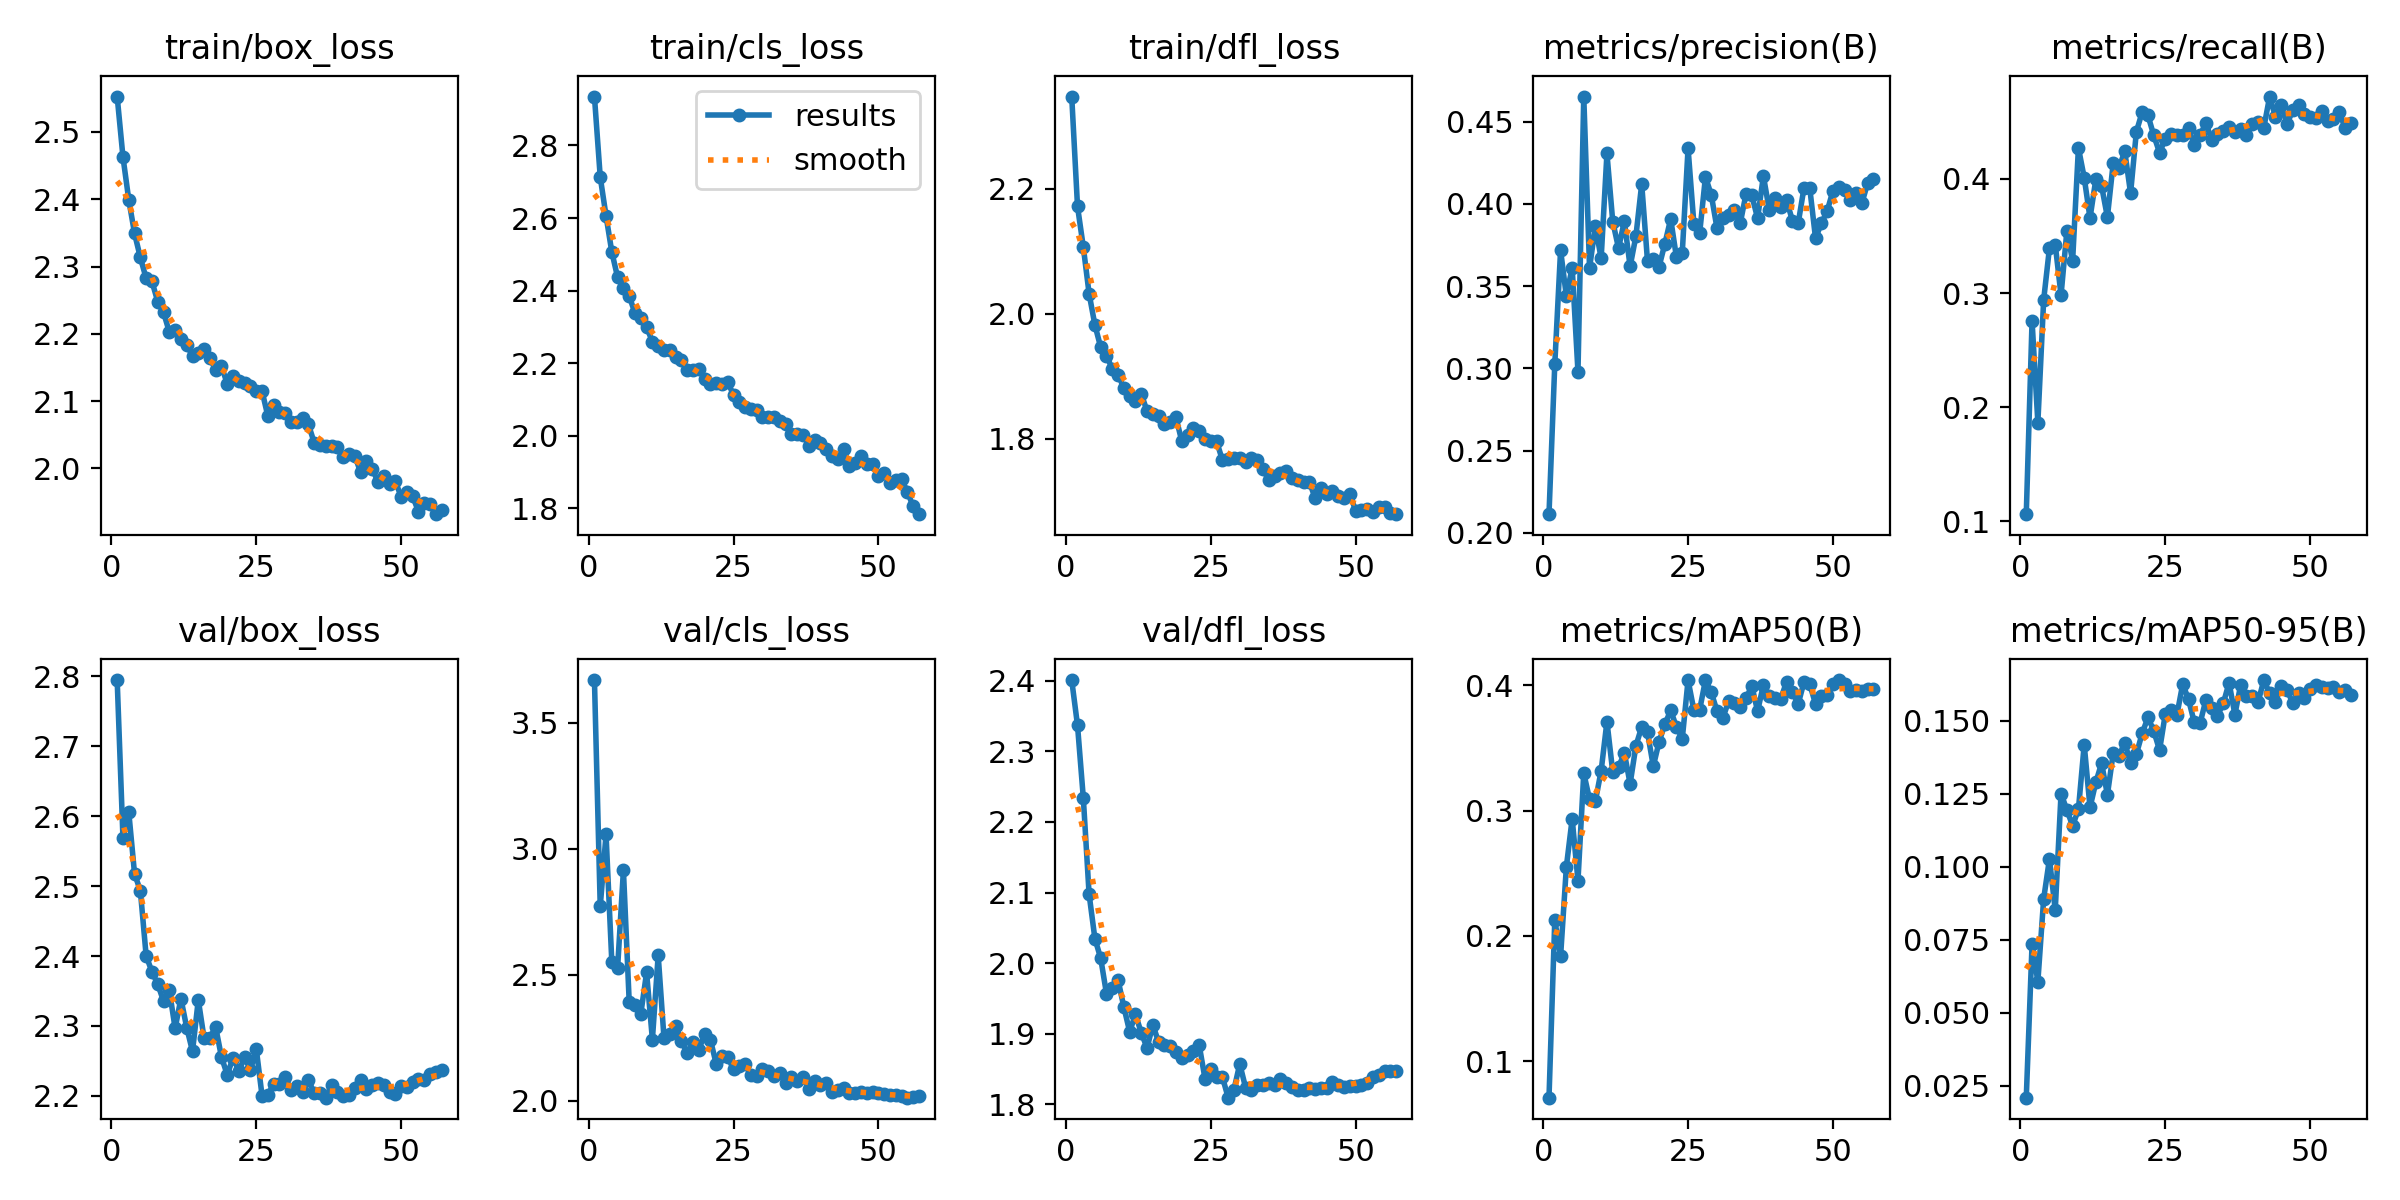

— confusion_matrix_normalized.png


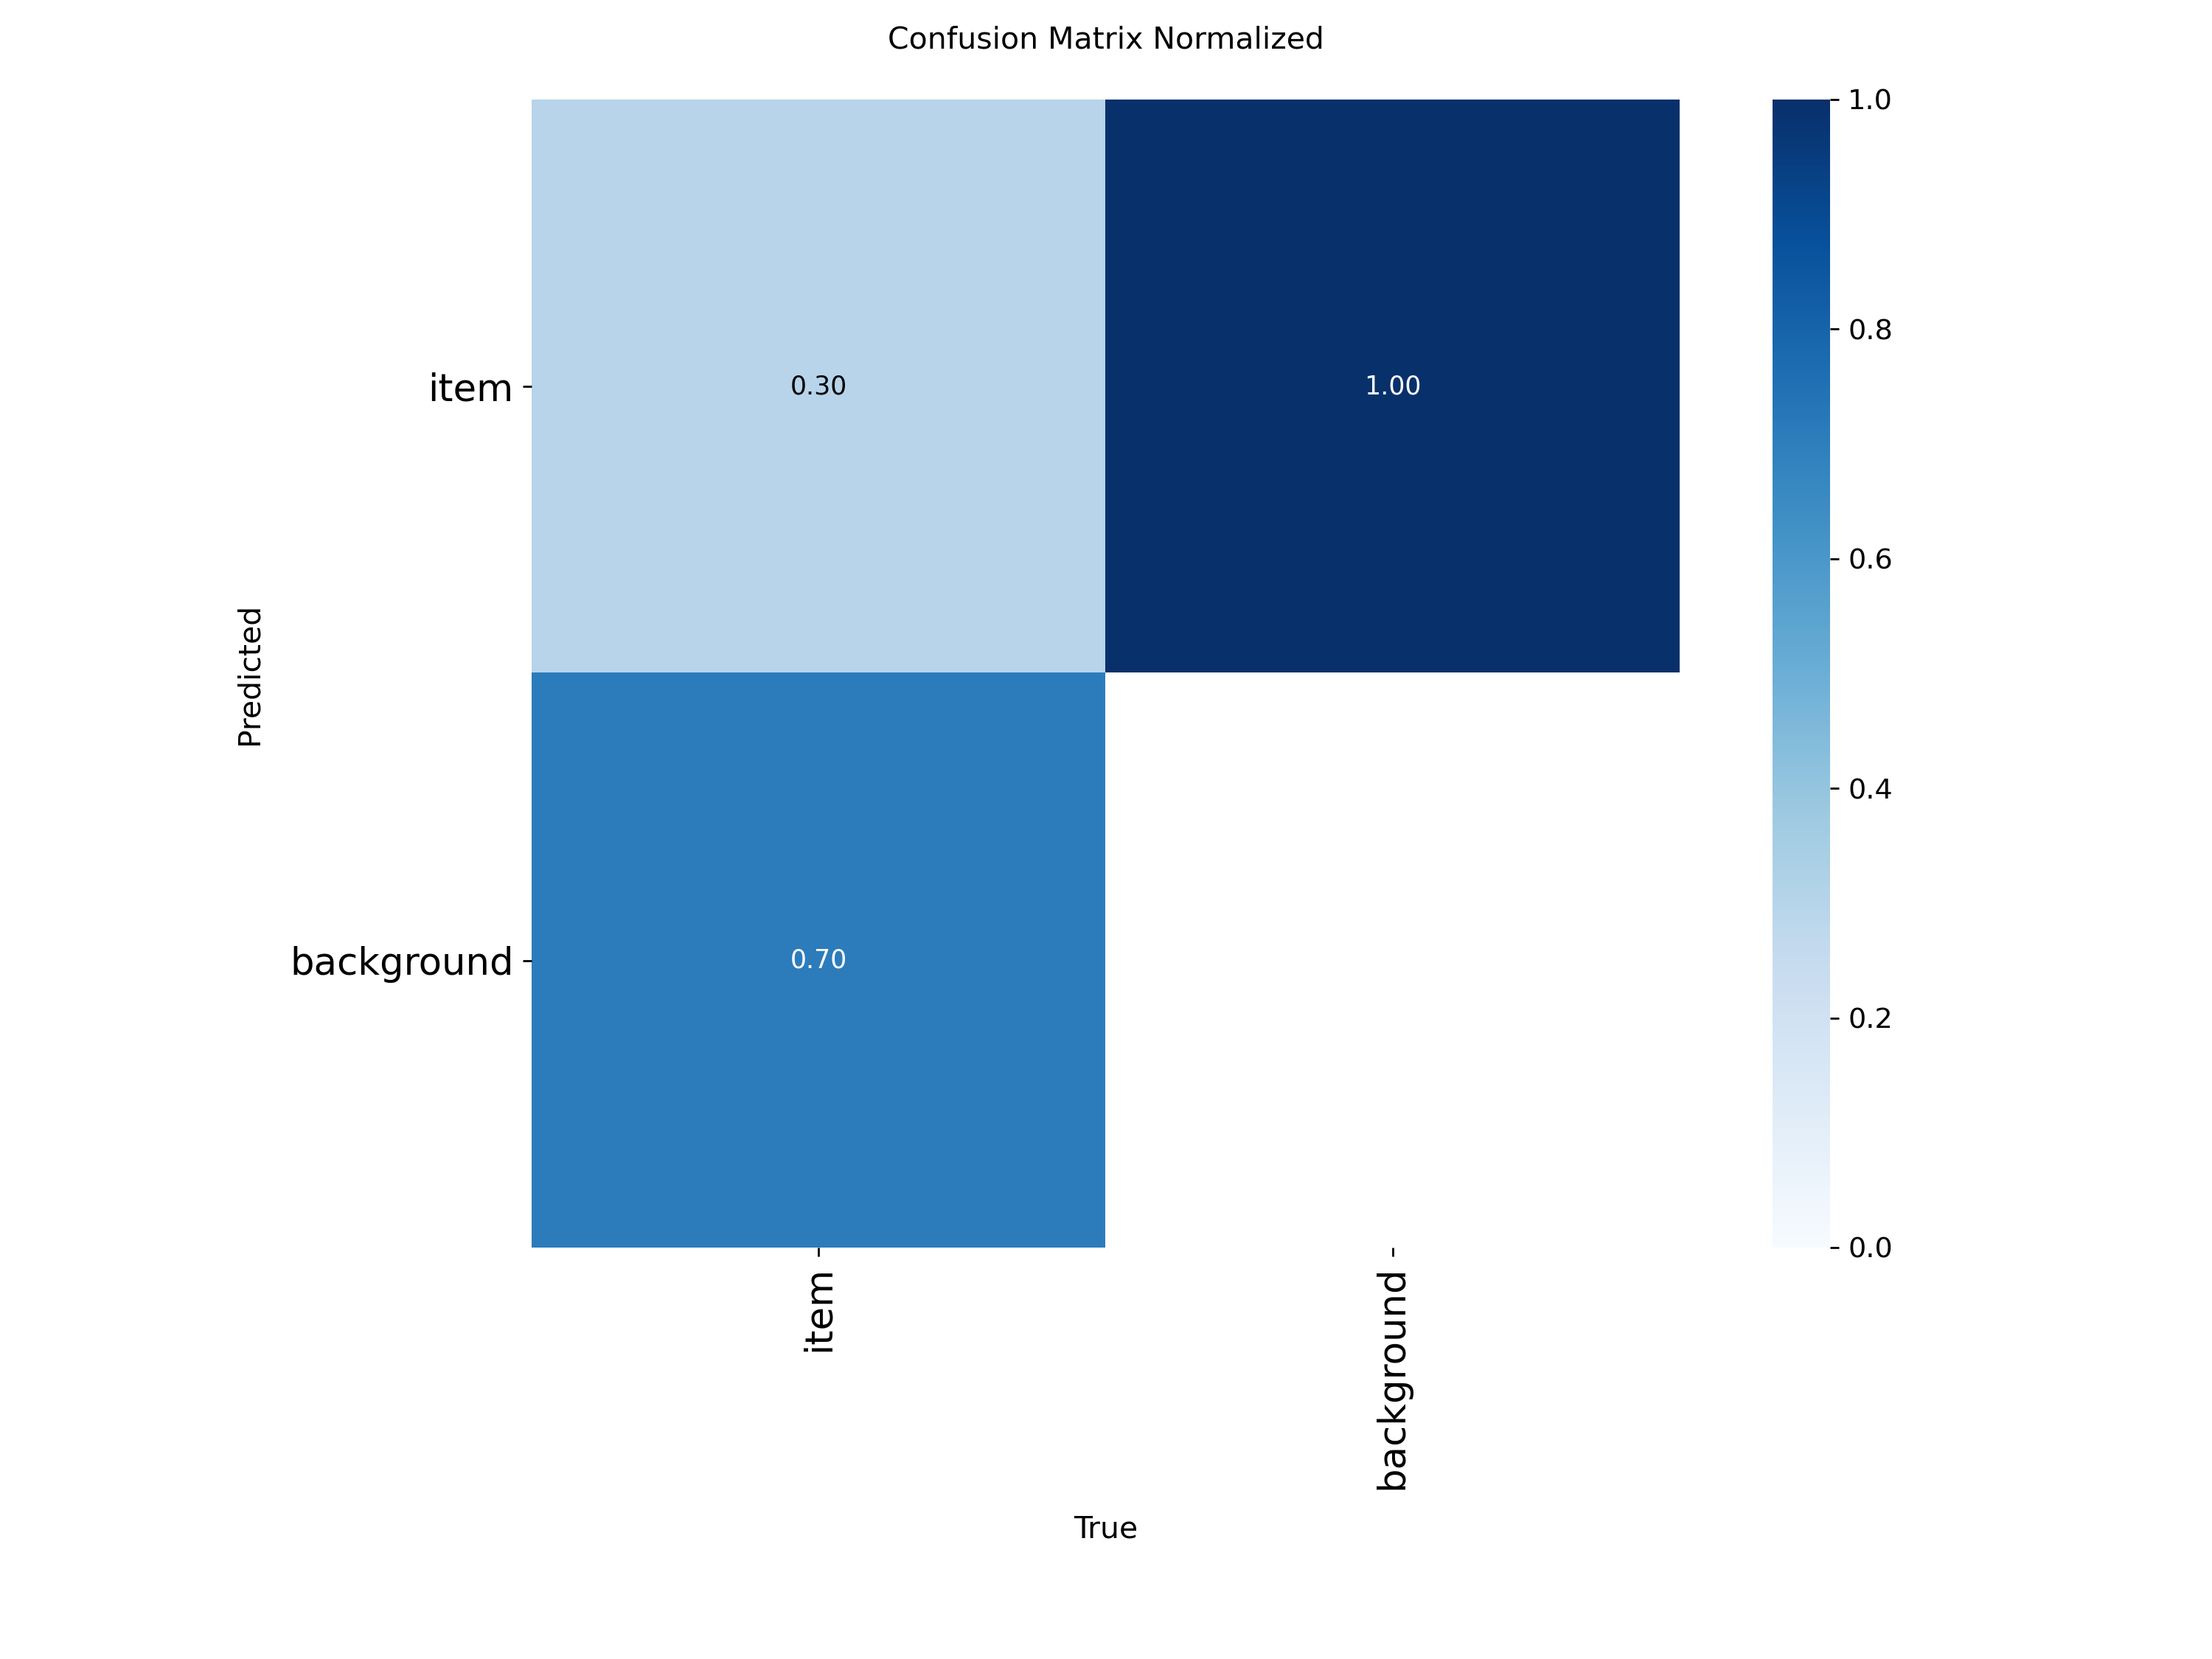

— val_batch0_pred.jpg


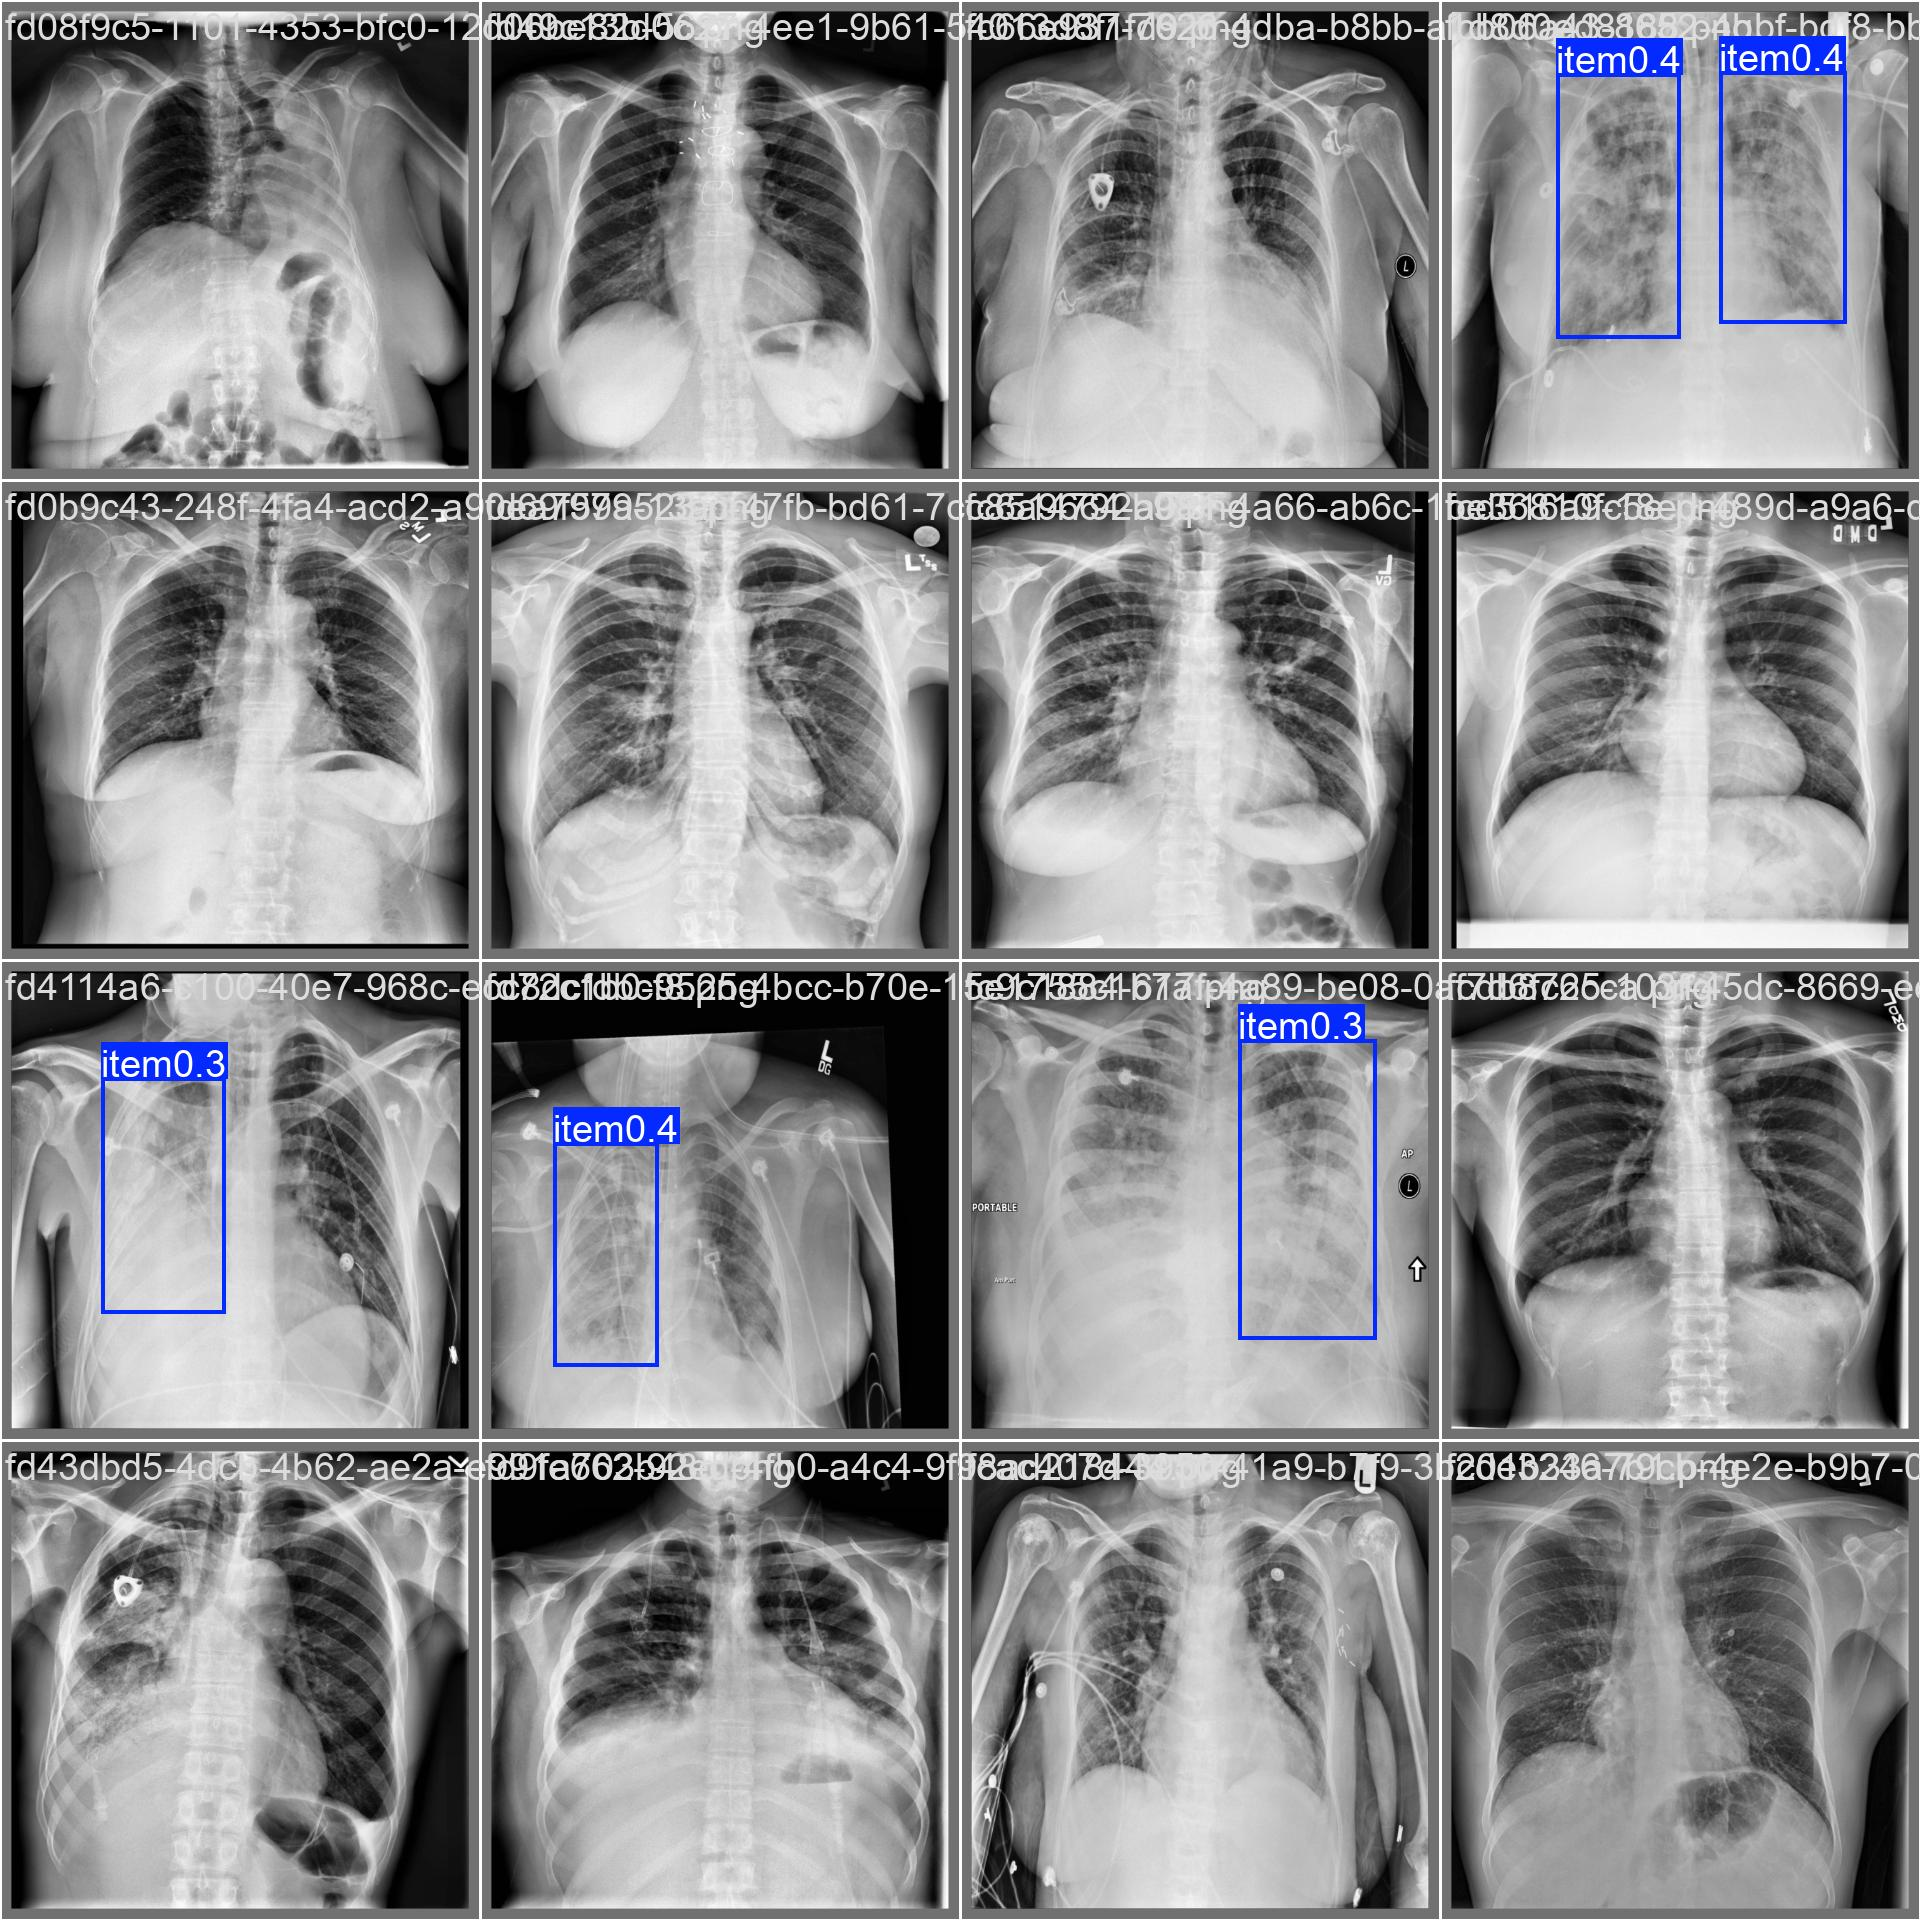

In [10]:
from IPython.display import Image as IPImage, display as dsp
for f in ['results.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png',
          'F1_curve.png', 'confusion_matrix_normalized.png', 'val_batch0_pred.jpg']:
    chemin = f'{RUN_DIR}/{f}'
    if os.path.exists(chemin):
        print('—', f); dsp(IPImage(filename=chemin, width=780))


## 6. Comparaison de toutes les versions

In [11]:
v2 = {'Precision (P)': 0.4321, 'Rappel (R)': 0.5345, 'mAP@0.5': 0.3961, 'F1': 0.4778}
v3 = {'Precision (P)': 0.381,  'Rappel (R)': 0.463,  'mAP@0.5': 0.367,  'F1': round(2*0.381*0.463/(0.381+0.463+1e-9), 4)}
v4 = {'Precision (P)': 0.412,  'Rappel (R)': 0.460,  'mAP@0.5': 0.406,  'F1': round(2*0.412*0.460/(0.412+0.460+1e-9), 4)}
v5 = tableau.iloc[0].to_dict()

comparaison = pd.DataFrame([v2, v3, v4, v5], index=[
    'v2 (ratio 1:1, 45 epochs, sans CLAHE)',
    'v3 (ratio 1:2, coupe epoch 61/100)',
    'v4 (ratio 1:1.5, CLAHE, coupe epoch 55/60)',
    'v5 (ratio 1:1.5, CLAHE, 70 epochs)',
])
display(comparaison)
comparaison.to_csv('/kaggle/working/comparaison_toutes_versions.csv')


,Precision (P),Rappel (R),mAP@0.5,F1,mAP@0.5:0.95
"v2 (ratio 1:1, 45 epochs, sans CLAHE)",0.4321,0.5345,0.3961,0.4778,NaN
"v3 (ratio 1:2, coupe epoch 61/100)",0.3810,0.4630,0.3670,0.4180,NaN
"v4 (ratio 1:1.5, CLAHE, coupe epoch 55/60)",0.4120,0.4600,0.4060,0.4347,NaN
"v5 (ratio 1:1.5, CLAHE, 70 epochs)",0.4034,0.4451,0.4035,0.4232,0.164


In [12]:
from IPython.display import FileLink
display(FileLink(f'{RUN_DIR}/weights/best.pt'))
display(FileLink(f'{RUN_DIR}/weights/last.pt'))
display(FileLink('/kaggle/working/metriques_finales_v5.csv'))
display(FileLink('/kaggle/working/balayage_seuil_v5.csv'))
display(FileLink('/kaggle/working/comparaison_toutes_versions.csv'))


/kaggle/working/pneumoscan_runs/pneumoscan_yolo11m_v5/weights/best.pt

/kaggle/working/pneumoscan_runs/pneumoscan_yolo11m_v5/weights/last.pt

/kaggle/working/metriques_finales_v5.csv

/kaggle/working/balayage_seuil_v5.csv

/kaggle/working/comparaison_toutes_versions.csv

---
## Aide-mémoire — en cas d'interruption

1. **Your Work → Notebooks → cette version → Output**
2. Télécharge `weights/last.pt`
3. **Datasets → New Dataset** → upload ce fichier → nomme-le exactement `pneumoscan-v5-checkpoint`
4. Retourne dans ce notebook, **Add Input** → rattache `pneumoscan-v5-checkpoint`
5. **Save Version → Save & Run All (Commit)** — la cellule 0 va détecter le checkpoint et reprendre automatiquement, sans que tu aies besoin de modifier une seule ligne de code.

Répète autant de fois que nécessaire jusqu'à ce qu'un commit se termine sans interruption.